In [54]:
import os
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchvision.models.vision_transformer import vit_b_16, ViT_B_16_Weights

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [55]:
# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(224),   # 🔥 IMPORTANT (removes borders)
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(224),   # 🔥 IMPORTANT
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Directories
base_dir = '/kaggle/input/tuberculosisdata/TB_Data'
train_dir = os.path.join(base_dir, 'Train')
val_dir = os.path.join(base_dir, 'Validation')
test_dir = os.path.join(base_dir, 'Test')

# Datasets & Dataloaders
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = train_dataset.classes
print("✅ Classes:", class_names)


✅ Classes: ['Normal', 'Tuberculosis']


In [56]:
# Load pretrained ViT
vit_model = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)

# Modify classifier for binary classification
in_features = vit_model.heads[0].in_features
vit_model.heads.head = nn.Linear(in_features, 2)
vit_model = vit_model.to(device)


In [57]:
import os

# Base dataset path
base_path = "/kaggle/input/tuberculosisdata/TB_Data"

# Function to count images in each subfolder
def count_images(folder_path):
    counts = {}
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            counts[class_name] = num_images
    return counts

# Count for Train, Validation, Test
train_counts = count_images(os.path.join(base_path, "Train"))
val_counts = count_images(os.path.join(base_path, "Validation"))
test_counts = count_images(os.path.join(base_path, "Test"))

# Print the results
print("📊 Train Set Image Counts:", train_counts)
print("📊 Validation Set Image Counts:", val_counts)
print("📊 Test Set Image Counts:", test_counts)


📊 Train Set Image Counts: {'Tuberculosis': 2800, 'Normal': 2800}
📊 Validation Set Image Counts: {'Tuberculosis': 350, 'Normal': 350}
📊 Test Set Image Counts: {'Tuberculosis': 350, 'Normal': 350}


In [58]:
# Compute class weights
class_counts = [len(os.listdir(os.path.join(train_dir, c))) for c in class_names]
weights = torch.tensor(class_counts, dtype=torch.float)
weights = 1.0 / weights
weights = weights / weights.sum()
weighted_loss = nn.CrossEntropyLoss(
    weight=weights.to(device),
    label_smoothing=0.1   # 🔥 IMPORTANT
)

# Optimizer
optimizer = torch.optim.AdamW(
    vit_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4   # 🔥 IMPORTANT
)


In [59]:
def evaluate_model(model, loader, criterion):
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return val_loss / len(loader), correct / total

# Store metrics for plotting
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

def train_model(model, criterion, optimizer, train_loader, val_loader, epochs=20):
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        avg_train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        val_loss, val_acc = evaluate_model(model, val_loader, criterion)

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"📉 Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"📈 Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Save best model (optional, still kept)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")


In [60]:
train_model(vit_model, weighted_loss, optimizer, train_loader, val_loader, epochs=40)


Epoch 1/40: 100%|██████████| 175/175 [02:38<00:00,  1.10it/s]


📉 Train Loss: 0.2867, Train Acc: 0.9511
📈 Val Loss: 0.4272, Val Acc: 0.8700


Epoch 2/40: 100%|██████████| 175/175 [02:40<00:00,  1.09it/s]


📉 Train Loss: 0.2402, Train Acc: 0.9764
📈 Val Loss: 0.2399, Val Acc: 0.9771


Epoch 3/40: 100%|██████████| 175/175 [02:40<00:00,  1.09it/s]


...

📉 Train Loss: 0.2157, Train Acc: 0.9904
📈 Val Loss: 0.2014, Val Acc: 0.9986


Epoch 39/40: 100%|██████████| 175/175 [02:40<00:00,  1.09it/s]


📉 Train Loss: 0.2145, Train Acc: 0.9914
📈 Val Loss: 0.2059, Val Acc: 0.9957


Epoch 40/40: 100%|██████████| 175/175 [02:39<00:00,  1.09it/s]


📉 Train Loss: 0.2117, Train Acc: 0.9929
📈 Val Loss: 0.2248, Val Acc: 0.9843


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Glyph 129514 (\N{TEST TUBE}) missing from current font.


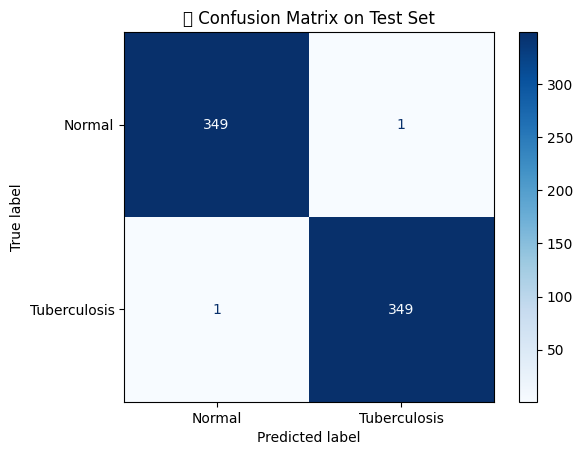

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       350
Tuberculosis       1.00      1.00      1.00       350

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700



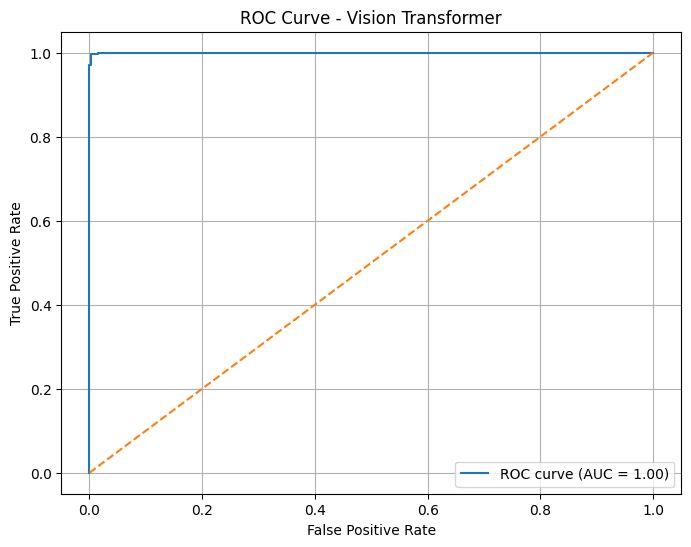

In [61]:
# Load best model
vit_model.load_state_dict(torch.load("best_model.pth"))
vit_model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = vit_model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("🧪 Confusion Matrix on Test Set")
plt.show()

# Classification Report
print("📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = roc_auc_score(all_labels, all_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Vision Transformer")
plt.legend()
plt.grid()
plt.show()


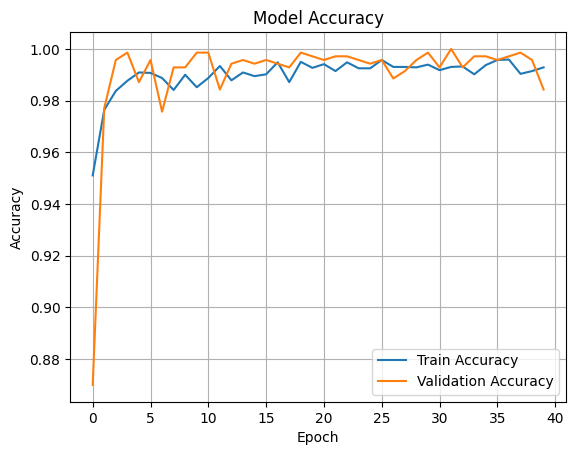

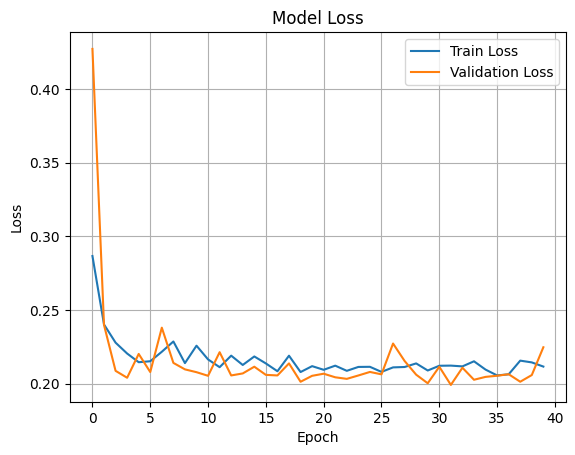

In [63]:
# Accuracy Curve
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid()
plt.show()

# Loss Curve
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid()
plt.show()


In [64]:
print("📊 Accuracy per Epoch:")
print(f"{'Epoch':<6} {'Train Accuracy (%)':<20} {'Val Accuracy (%)':<20}")
print("-" * 50)

for epoch, (train_acc, val_acc) in enumerate(zip(train_accuracies, val_accuracies), start=1):
    print(f"{epoch:<6} {train_acc * 100:<20.2f} {val_acc * 100:<20.2f}")


📊 Accuracy per Epoch:
Epoch  Train Accuracy (%)   Val Accuracy (%)    
--------------------------------------------------
1      95.11                87.00               
2      97.64                97.71               
3      98.38                99.57               
4      98.77                99.86               
5      99.09                98.71               
6      99.07                99.57               
7      98.88                97.57               
8      98.41                99.29               
9      99.00                99.29               
10     98.52                99.86               
11     98.88                99.86               
12     99.34                98.43               
13     98.79                99.43               
14     99.09                99.57               
15     98.95                99.43               
16     99.02                99.57               
17     99.48                99.43               
18     98.71                99.29            

In [65]:
from sklearn.metrics import accuracy_score

def get_final_accuracy(model, loader, set_name="Set"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"✅ Final Accuracy on {set_name}: {acc * 100:.2f}%")
    return acc * 100

# Make sure your best model is loaded
vit_model.load_state_dict(torch.load("best_model.pth"))

# Calculate accuracies
final_train_acc = get_final_accuracy(vit_model, train_loader, "Train Set")
final_val_acc = get_final_accuracy(vit_model, val_loader, "Validation Set")
final_test_acc = get_final_accuracy(vit_model, test_loader, "Test Set")


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


✅ Final Accuracy on Train Set: 99.11%
✅ Final Accuracy on Validation Set: 100.00%
✅ Final Accuracy on Test Set: 99.71%


In [66]:
from PIL import Image

# Path to the uploaded image
image_path = '/kaggle/input/tuberculosisdata/TB_Data/Test/Normal/Normal-1009.png'  # change this if needed

# Load and preprocess the image
image = Image.open(image_path).convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

input_tensor = transform(image).unsqueeze(0).to(device)

# Load your trained model
vit_model.eval()
with torch.no_grad():
    output = vit_model(input_tensor)
    predicted_class = torch.argmax(output, 1).item()

# Class names (ensure it matches your training dataset)
class_names = ['Normal', 'Tuberculosis']
print(f"✅ Predicted Class: {class_names[predicted_class]}")


✅ Predicted Class: Normal


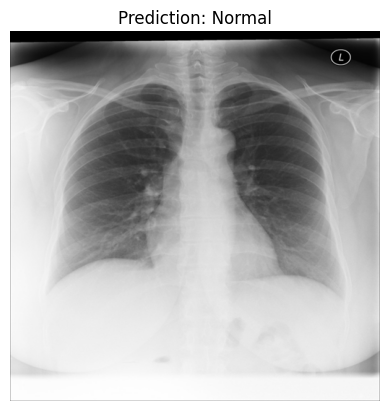

In [67]:
plt.imshow(image)
plt.axis('off')
plt.title(f"Prediction: {class_names[predicted_class]}")
plt.show()


In [68]:
from PIL import Image

# Path to the uploaded image
image_path = '/kaggle/input/tuberculosisdata/TB_Data/Test/Tuberculosis/Tuberculosis-113_aug0.png'  # change this if needed

# Load and preprocess the image
image = Image.open(image_path).convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

input_tensor = transform(image).unsqueeze(0).to(device)

# Load your trained model
vit_model.eval()
with torch.no_grad():
    output = vit_model(input_tensor)
    predicted_class = torch.argmax(output, 1).item()

# Class names (ensure it matches your training dataset)
class_names = ['Normal', 'Tuberculosis']
print(f"✅ Predicted Class: {class_names[predicted_class]}")


✅ Predicted Class: Tuberculosis


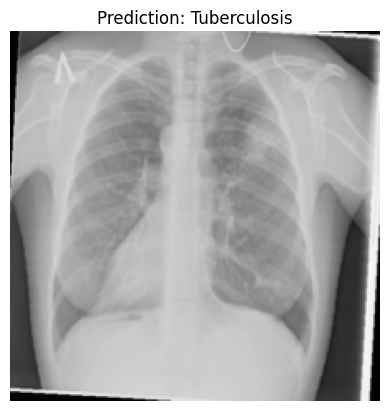

In [69]:
plt.imshow(image)
plt.axis('off')
plt.title(f"Prediction: {class_names[predicted_class]}")
plt.show()


In [70]:
!pip install captum


In [71]:
# ====================================================
# Captum Imports
# ====================================================
from captum.attr import IntegratedGradients, NoiseTunnel, Occlusion
import matplotlib.pyplot as plt
import gc


In [72]:
# ====================================================
# Captum Explainability for Vision Transformer
# ====================================================

# Free GPU memory
gc.collect()
torch.cuda.empty_cache()

# Move model & input to CPU for Captum (to avoid OOM)
vit_model_cpu = vit_model.cpu()
input_for_attr_cpu = input_tensor.clone().detach().requires_grad_(True).cpu()

# Integrated Gradients
ig = IntegratedGradients(vit_model_cpu)
attr_ig = ig.attribute(input_for_attr_cpu, target=predicted_class, n_steps=10)

# Occlusion
occlusion = Occlusion(vit_model_cpu)
attr_occ = occlusion.attribute(input_for_attr_cpu, target=predicted_class,
                               strides=(3,30,30),
                               sliding_window_shapes=(3,60,60),
                               baselines=0)

# Convert attribution tensors to normalized grayscale maps
def to_grayscale_norm(attr_tensor):
    attr = attr_tensor.abs().mean(dim=1).squeeze(0)
    attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)
    return attr.detach().cpu().numpy()

attr_ig_map  = to_grayscale_norm(attr_ig)
attr_occ_map = to_grayscale_norm(attr_occ)

print("✅ Captum attributions computed")


✅ Captum attributions computed


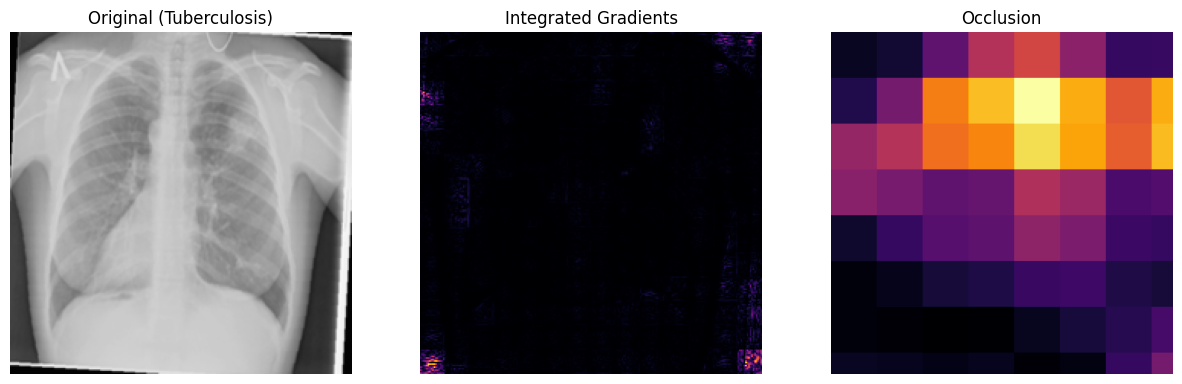

In [73]:
# ====================================================
# Visualization of Captum Attributions
# ====================================================
fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Original Image
axes[0].imshow(image)
axes[0].set_title(f"Original ({class_names[predicted_class]})")
axes[0].axis("off")

# Integrated Gradients
axes[1].imshow(attr_ig_map, cmap="inferno")
axes[1].set_title("Integrated Gradients")
axes[1].axis("off")

# Occlusion
axes[2].imshow(attr_occ_map, cmap="inferno")
axes[2].set_title("Occlusion")
axes[2].axis("off")

plt.show()


✅ Prediction: Tuberculosis (95.66% confidence)


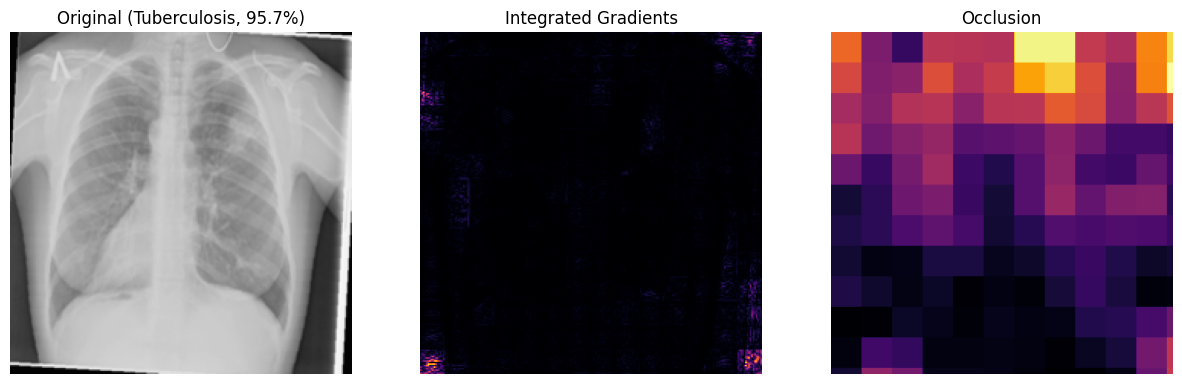

In [74]:
# ====================================================
# Captum Explainability for Vision Transformer
# ====================================================
import torch.nn.functional as F
from captum.attr import IntegratedGradients, Occlusion
import matplotlib.pyplot as plt
import numpy as np

# Make sure model and input are on same device
vit_model = vit_model.to(device)
input_tensor = input_tensor.to(device)

# --- Get prediction + confidence ---
vit_model.eval()
with torch.no_grad():
    outputs = vit_model(input_tensor)
    probs = F.softmax(outputs, dim=1)
    confidence, predicted_class = torch.max(probs, 1)

pred_label = class_names[predicted_class.item()]
conf_value = confidence.item() * 100
print(f"✅ Prediction: {pred_label} ({conf_value:.2f}% confidence)")

# --- Captum Attributions ---
input_for_attr = input_tensor.clone().detach().requires_grad_(True)

# Integrated Gradients
ig = IntegratedGradients(vit_model)
attr_ig = ig.attribute(input_for_attr, target=predicted_class.item(), n_steps=20)

# Occlusion (patch-based sensitivity)
occlusion = Occlusion(vit_model)
attr_occ = occlusion.attribute(
    input_for_attr,
    target=predicted_class.item(),
    strides=(3, 20, 20),
    sliding_window_shapes=(3, 40, 40),
    baselines=0
)

# Convert attribution tensor -> grayscale heatmap
def to_grayscale(attr_tensor):
    attr = attr_tensor.abs().mean(dim=1).squeeze(0).detach()
    attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)
    return attr.cpu().numpy()

attr_ig_map  = to_grayscale(attr_ig)
attr_occ_map = to_grayscale(attr_occ)

# --- Visualization ---
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axs[0].imshow(image)
axs[0].set_title(f"Original ({pred_label}, {conf_value:.1f}%)")
axs[0].axis("off")

# Integrated Gradients heatmap
axs[1].imshow(attr_ig_map, cmap="inferno")
axs[1].set_title("Integrated Gradients")
axs[1].axis("off")

# Occlusion heatmap
axs[2].imshow(attr_occ_map, cmap="inferno")
axs[2].set_title("Occlusion")
axs[2].axis("off")

plt.show()


✅ Prediction for Normal Image: Normal (95.26% confidence)


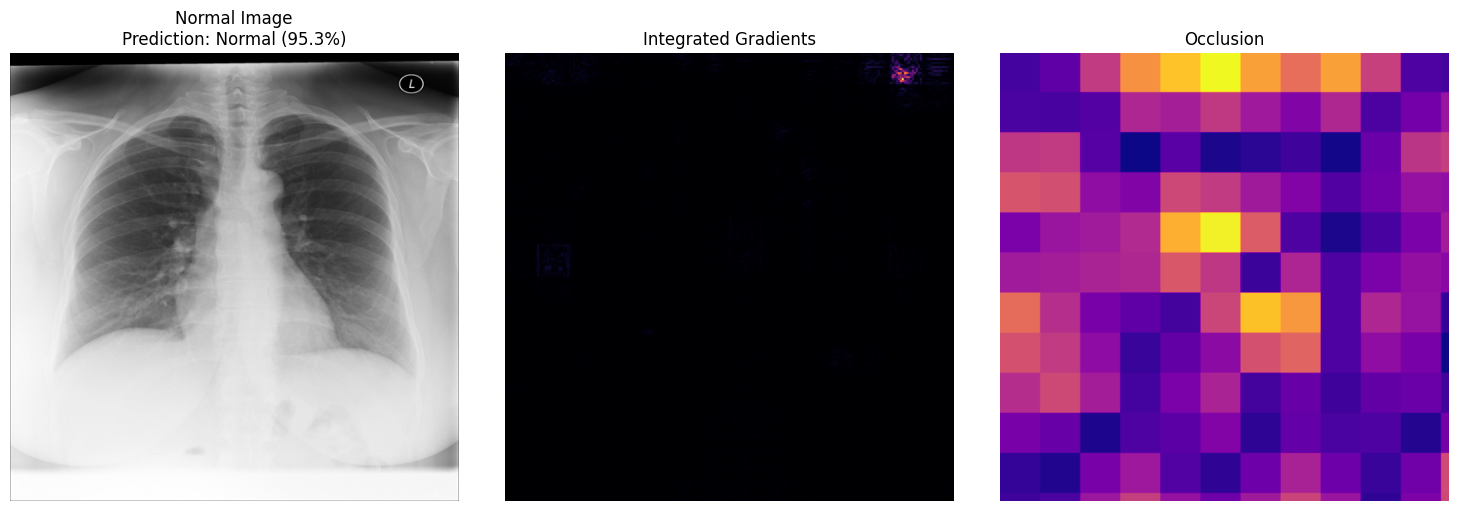

In [75]:
# ====================================================
# 8. Test on Normal Image + Captum Visualization
# ====================================================
from captum.attr import IntegratedGradients, Occlusion
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Load a Normal image
normal_image_path = "/kaggle/input/tuberculosisdata/TB_Data/Test/Normal/Normal-1009.png"
normal_image = Image.open(normal_image_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

input_tensor = transform(normal_image).unsqueeze(0).to(device)

# Get prediction + confidence
vit_model.eval()
with torch.no_grad():
    outputs = vit_model(input_tensor)
    probs = F.softmax(outputs, dim=1)
    confidence, predicted_class = torch.max(probs, 1)

pred_label = class_names[predicted_class.item()]
pred_conf = confidence.item() * 100

print(f"✅ Prediction for Normal Image: {pred_label} ({pred_conf:.2f}% confidence)")

# Captum: Integrated Gradients
ig = IntegratedGradients(vit_model)
attr_ig = ig.attribute(input_tensor, target=predicted_class.item(), n_steps=50)

# Captum: Occlusion
occlusion = Occlusion(vit_model)
attr_occ = occlusion.attribute(
    input_tensor,
    strides=(3, 20, 20),
    sliding_window_shapes=(3, 40, 40),
    target=predicted_class.item()
)

# Convert to grayscale maps
def to_grayscale(attr_tensor):
    attr = attr_tensor.detach().abs().mean(dim=1).squeeze(0)
    attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)
    return attr.cpu().numpy()

ig_map = to_grayscale(attr_ig)
occ_map = to_grayscale(attr_occ)

# Visualization
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(normal_image, cmap="gray")
axs[0].set_title(f"Normal Image\nPrediction: {pred_label} ({pred_conf:.1f}%)")
axs[0].axis("off")

axs[1].imshow(ig_map, cmap="inferno")
axs[1].set_title("Integrated Gradients")
axs[1].axis("off")

axs[2].imshow(occ_map, cmap="plasma")
axs[2].set_title("Occlusion")
axs[2].axis("off")

plt.tight_layout()
plt.show()


In [23]:
# ====================================================
# SHAP Explainability for Vision Transformer
# ====================================================

!pip install shap

import shap
import numpy as np
from PIL import Image

vit_model.eval()

# prediction function for SHAP
def shap_predict(images):
    
    images = torch.tensor(images).permute(0,3,1,2).float().to(device)

    with torch.no_grad():
        outputs = vit_model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)

    return probs.cpu().numpy()


def explain_with_shap(image_path):

    image = Image.open(image_path).convert("RGB")
    image = image.resize((224,224))
    image_np = np.array(image)

    # prediction
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = vit_model(input_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)

    confidence, pred_class = torch.max(probs,1)

    print("Prediction:", class_names[pred_class.item()])
    print("Confidence:", round(confidence.item()*100,2), "%")

    # SHAP image masker
    masker = shap.maskers.Image("blur(128,128)", image_np.shape)

    explainer = shap.Explainer(shap_predict, masker)

    shap_values = explainer(
        image_np[np.newaxis,...],
        max_evals=500,
        batch_size=50
    )

    shap.image_plot(shap_values)

    print("\nExplanation:")
    print("SHAP highlights image regions that contributed most to the model prediction.")

Prediction: Normal
Confidence: 99.99 %


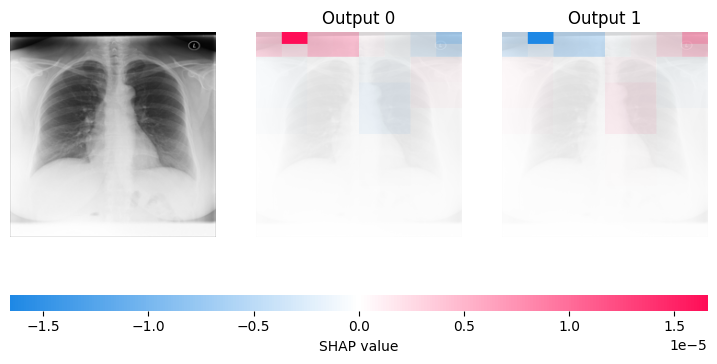


Explanation:
SHAP highlights image regions that contributed most to the model prediction.


In [24]:
explain_with_shap("/kaggle/input/tuberculosisdata/TB_Data/Test/Normal/Normal-1009.png")

Prediction: Tuberculosis
Confidence: 99.99 %


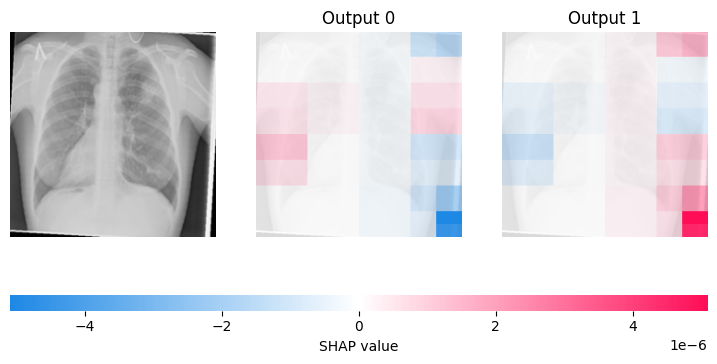


Explanation:
SHAP highlights image regions that contributed most to the model prediction.


In [27]:
explain_with_shap('/kaggle/input/tuberculosisdata/TB_Data/Test/Tuberculosis/Tuberculosis-113_aug0.png')

In [25]:
# ====================================================
# LIME Explainability for Vision Transformer
# ====================================================

!pip install lime

from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()

def lime_predict(images):

    images = torch.tensor(images).permute(0,3,1,2).float().to(device)

    with torch.no_grad():
        outputs = vit_model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)

    return probs.cpu().numpy()


def explain_with_lime(image_path):

    image = Image.open(image_path).convert("RGB")
    image = image.resize((224,224))
    image_np = np.array(image)

    # prediction
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = vit_model(input_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)

    confidence, pred_class = torch.max(probs,1)

    print("Prediction:", class_names[pred_class.item()])
    print("Confidence:", round(confidence.item()*100,2), "%")

    explanation = explainer.explain_instance(
        image_np,
        lime_predict,
        top_labels=2,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    plt.figure(figsize=(6,6))
    plt.imshow(mark_boundaries(temp, mask))
    plt.title("LIME Explanation")
    plt.axis("off")

    print("\nExplanation:")
    print("LIME highlights superpixel regions that most influenced the model decision.")

Prediction: Normal
Confidence: 99.99 %


  0%|          | 0/1000 [00:00<?, ?it/s]


Explanation:
LIME highlights superpixel regions that most influenced the model decision.


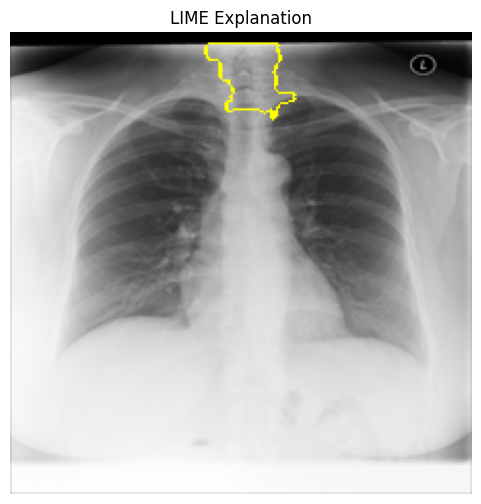

In [26]:
explain_with_lime("/kaggle/input/tuberculosisdata/TB_Data/Test/Normal/Normal-1009.png")

Prediction: Tuberculosis
Confidence: 100.0 %


  0%|          | 0/1000 [00:00<?, ?it/s]


Explanation:
LIME highlights superpixel regions that most influenced the model decision.


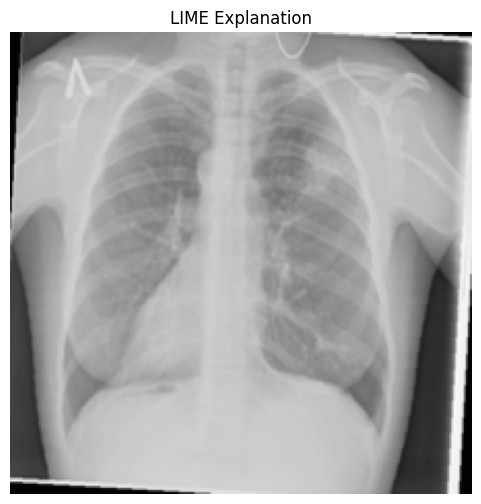

In [27]:
explain_with_lime('/kaggle/input/tuberculosisdata/TB_Data/Test/Tuberculosis/Tuberculosis-113_aug0.png')

Prediction: Tuberculosis
Confidence Score: 100.0 %


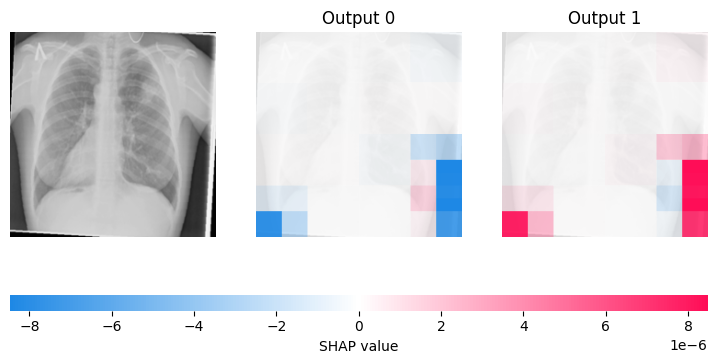


Explanation:
SHAP highlights regions in the chest X-ray that increased the probability of Tuberculosis.


In [28]:
# ====================================================
# SHAP Explainability for Vision Transformer
# ====================================================

!pip install shap

import shap
import numpy as np
import torch
from PIL import Image

vit_model.eval()

# prediction function for SHAP
def shap_predict(images):

    images = torch.tensor(images).permute(0,3,1,2).float().to(device)

    with torch.no_grad():
        outputs = vit_model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)

    return probs.cpu().numpy()


def explain_with_shap(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")
    image = image.resize((224,224))
    image_np = np.array(image)

    input_tensor = transform(image).unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        outputs = vit_model(input_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)

    confidence, pred_class = torch.max(probs,1)

    prediction = class_names[pred_class.item()]
    confidence = round(confidence.item()*100,2)

    print("Prediction:", prediction)
    print("Confidence Score:", confidence,"%")

    # SHAP masker (smaller blur = clearer explanation)
    masker = shap.maskers.Image("blur(32,32)", image_np.shape)

    explainer = shap.Explainer(shap_predict, masker)

    shap_values = explainer(
        image_np[np.newaxis,...],
        max_evals=500,
        batch_size=50
    )

    shap.image_plot(shap_values)

    # Explanation text
    if prediction == "Tuberculosis":
        print("\nExplanation:")
        print("SHAP highlights regions in the chest X-ray that increased the probability of Tuberculosis.")
    else:
        print("\nExplanation:")
        print("SHAP highlights regions supporting the Normal lung classification.")


# Run explanation
explain_with_shap('/kaggle/input/tuberculosisdata/TB_Data/Test/Tuberculosis/Tuberculosis-113_aug0.png')

Prediction: Normal
Confidence Score: 99.99 %


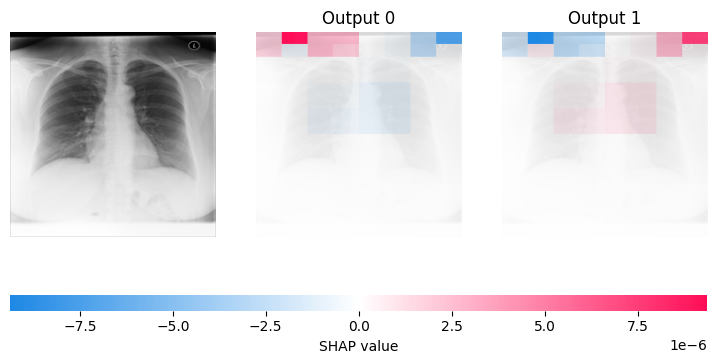


Explanation:
SHAP highlights regions supporting the Normal lung classification.


In [29]:
explain_with_shap("/kaggle/input/tuberculosisdata/TB_Data/Test/Normal/Normal-1009.png")

Prediction: Normal
Confidence Score: 99.99 %


  0%|          | 0/1500 [00:00<?, ?it/s]


Explanation:
LIME highlights image regions supporting the Normal lung classification.


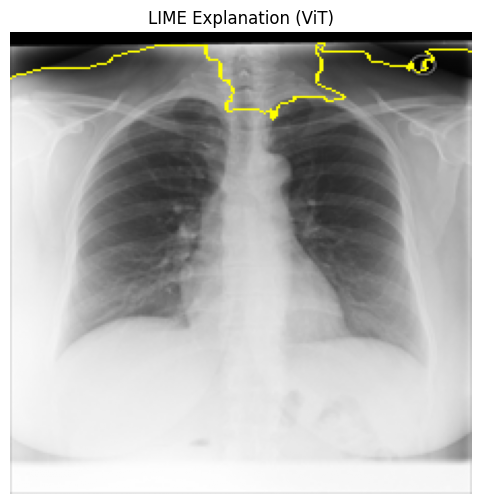

In [30]:
# ====================================================
# LIME Explainability for Vision Transformer
# ====================================================

!pip install lime

from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

explainer = lime_image.LimeImageExplainer()

def lime_predict(images):

    images = torch.tensor(images).permute(0,3,1,2).float().to(device)

    with torch.no_grad():
        outputs = vit_model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)

    return probs.cpu().numpy()


def explain_with_lime(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")
    image = image.resize((224,224))
    image_np = np.array(image)

    # Model prediction
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = vit_model(input_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)

    confidence, pred_class = torch.max(probs,1)

    prediction = class_names[pred_class.item()]
    confidence = round(confidence.item()*100,2)

    print("Prediction:", prediction)
    print("Confidence Score:", confidence,"%")

    # LIME explanation
    explanation = explainer.explain_instance(
        image_np,
        lime_predict,
        top_labels=2,
        hide_color=0,
        num_samples=1500
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    plt.figure(figsize=(6,6))
    plt.imshow(mark_boundaries(temp, mask))
    plt.title("LIME Explanation (ViT)")
    plt.axis("off")

    # Explanation text
    if prediction == "Tuberculosis":
        print("\nExplanation:")
        print("LIME highlights image segments that contributed to the Tuberculosis prediction.")
    else:
        print("\nExplanation:")
        print("LIME highlights image regions supporting the Normal lung classification.")


# Run explanation
explain_with_lime("/kaggle/input/tuberculosisdata/TB_Data/Test/Normal/Normal-1009.png")

Prediction: Tuberculosis
Confidence Score: 100.0 %


  0%|          | 0/1500 [00:00<?, ?it/s]


Explanation:
LIME highlights image segments that contributed to the Tuberculosis prediction.


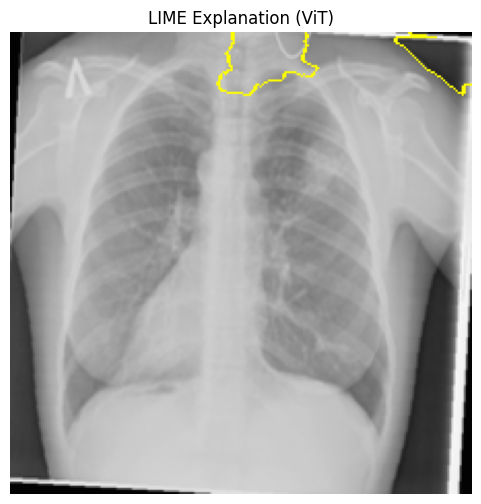

In [31]:
explain_with_lime('/kaggle/input/tuberculosisdata/TB_Data/Test/Tuberculosis/Tuberculosis-113_aug0.png')

In [76]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

def gradcam_vit_correct(vit_model, image_path):

    vit_model.eval()
    vit_model.cpu()

    image = Image.open(image_path).convert("RGB").resize((224,224))
    input_tensor = transform(image).unsqueeze(0)

    gradients = []
    activations = []

    # ✅ FIXED: Correct layer for torchvision ViT
    target_layer = vit_model.encoder.layers[-1].ln_1

    def forward_hook(module, input, output):
        activations.clear()
        activations.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.clear()
        gradients.append(grad_out[0])

    # ✅ safer hook
    target_layer.register_forward_hook(forward_hook)
    target_layer.register_full_backward_hook(backward_hook)

    # Forward
    output = vit_model(input_tensor)
    probs = torch.softmax(output, dim=1)

    confidence, pred_class = torch.max(probs, 1)
    prediction = class_names[pred_class.item()]
    confidence = round(confidence.item()*100, 2)

    # Backward
    vit_model.zero_grad()
    output[0, pred_class].backward()

    grads = gradients[0]   # (B, Tokens, C)
    acts = activations[0]  # (B, Tokens, C)

    # ❗ Remove CLS token
    grads = grads[:, 1:, :]
    acts = acts[:, 1:, :]

    # Convert tokens → feature map
    size = int((acts.shape[1]) ** 0.5)

    grads = grads.reshape(1, size, size, -1).permute(0, 3, 1, 2)
    acts = acts.reshape(1, size, size, -1).permute(0, 3, 1, 2)

    # Grad-CAM
    weights = grads.mean(dim=[2,3], keepdim=True)
    cam = (weights * acts).sum(dim=1).squeeze()

    cam = torch.relu(cam)
    cam = cam / (cam.max() + 1e-8)

    cam = cam.detach().numpy()
    cam = cv2.resize(cam, (224,224))

    # Plot
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.imshow(cam, cmap='jet', alpha=0.5)
    plt.title("Grad-CAM (ViT)")
    plt.axis("off")

    # Output
    print("\nPrediction:", prediction)
    print("Confidence Score:", confidence, "%")

    print("\nExplanation:")
    if prediction == "Tuberculosis":
        print("Grad-CAM highlights important image patches contributing to the Tuberculosis prediction, indicating abnormal lung regions.")
    else:
        print("Grad-CAM highlights normal lung regions supporting the Normal classification.")


Prediction: Tuberculosis
Confidence Score: 95.66 %

Explanation:
Grad-CAM highlights important image patches contributing to the Tuberculosis prediction, indicating abnormal lung regions.


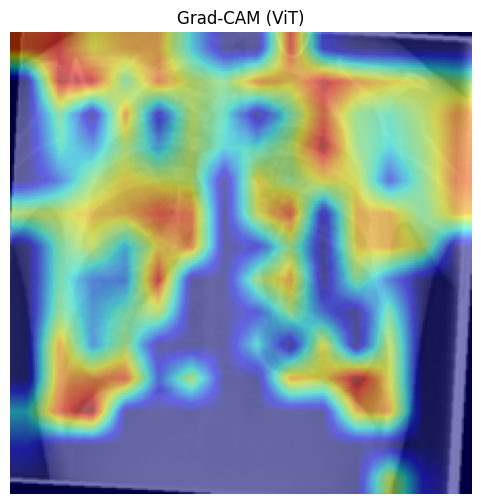

In [77]:
image_path = "/kaggle/input/tuberculosisdata/TB_Data/Test/Tuberculosis/Tuberculosis-113_aug0.png"
gradcam_vit_correct(vit_model, image_path)


Prediction: Normal
Confidence Score: 95.17 %

Explanation:
Grad-CAM highlights normal lung regions supporting the Normal classification.


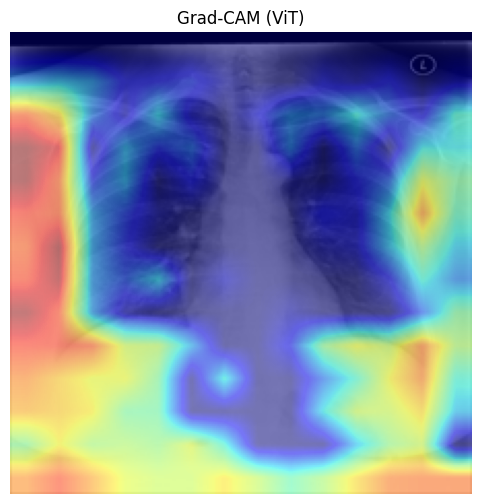

In [78]:
image_path = "/kaggle/input/tuberculosisdata/TB_Data/Test/Normal/Normal-1009.png"
gradcam_vit_correct(vit_model, image_path)

In [79]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

def gradcam_plus_plus_vit_correct(vit_model, image_path):

    vit_model.eval()
    vit_model.cpu()

    image = Image.open(image_path).convert("RGB").resize((224,224))
    input_tensor = transform(image).unsqueeze(0)

    gradients = []
    activations = []

    # ✅ FIXED: correct layer for torchvision ViT
    target_layer = vit_model.encoder.layers[-1].ln_1

    def forward_hook(module, input, output):
        activations.clear()
        activations.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.clear()
        gradients.append(grad_out[0])

    target_layer.register_forward_hook(forward_hook)
    target_layer.register_full_backward_hook(backward_hook)

    # Forward
    output = vit_model(input_tensor)
    probs = torch.softmax(output, dim=1)

    confidence, pred_class = torch.max(probs, 1)
    prediction = class_names[pred_class.item()]
    confidence = round(confidence.item()*100, 2)

    # Backward
    vit_model.zero_grad()
    output[0, pred_class].backward()

    grads = gradients[0]   # (B, Tokens, C)
    acts = activations[0]  # (B, Tokens, C)

    # ❗ Remove CLS token
    grads = grads[:, 1:, :]
    acts = acts[:, 1:, :]

    size = int((acts.shape[1]) ** 0.5)

    grads = grads.reshape(1, size, size, -1).permute(0, 3, 1, 2)
    acts = acts.reshape(1, size, size, -1).permute(0, 3, 1, 2)

    # Grad-CAM++
    grads_power_2 = grads ** 2
    grads_power_3 = grads ** 3

    sum_acts = acts.sum(dim=[2,3], keepdim=True)

    eps = 1e-8
    alpha = grads_power_2 / (2 * grads_power_2 + sum_acts * grads_power_3 + eps)

    positive_grads = torch.relu(grads)
    weights = (alpha * positive_grads).sum(dim=[2,3], keepdim=True)

    cam = (weights * acts).sum(dim=1).squeeze()

    cam = torch.relu(cam)
    cam = cam / (cam.max() + 1e-8)

    cam = cam.detach().numpy()
    cam = cv2.resize(cam, (224,224))

    # Plot
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.imshow(cam, cmap='jet', alpha=0.5)
    plt.title("Grad-CAM++ (ViT)")
    plt.axis("off")

    # Output
    print("\nPrediction:", prediction)
    print("Confidence Score:", confidence, "%")

    print("\nExplanation:")
    if prediction == "Tuberculosis":
        print("Grad-CAM++ provides more precise localization of multiple abnormal lung regions contributing to Tuberculosis prediction.")
    else:
        print("Grad-CAM++ highlights detailed normal lung structures supporting the Normal classification.")


Prediction: Tuberculosis
Confidence Score: 95.66 %

Explanation:
Grad-CAM++ provides more precise localization of multiple abnormal lung regions contributing to Tuberculosis prediction.


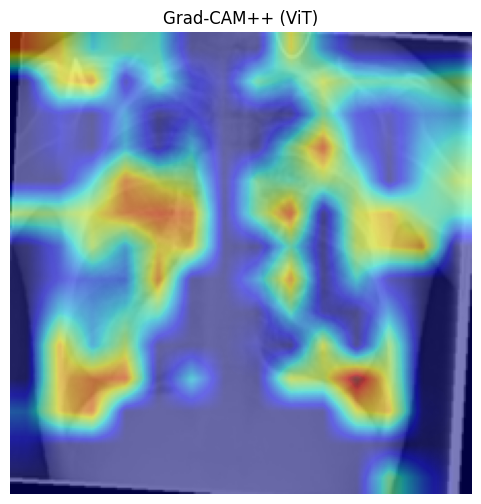

In [80]:
image_path = "/kaggle/input/tuberculosisdata/TB_Data/Test/Tuberculosis/Tuberculosis-113_aug0.png"
gradcam_plus_plus_vit_correct(vit_model, image_path)


Prediction: Normal
Confidence Score: 95.17 %

Explanation:
Grad-CAM++ highlights detailed normal lung structures supporting the Normal classification.


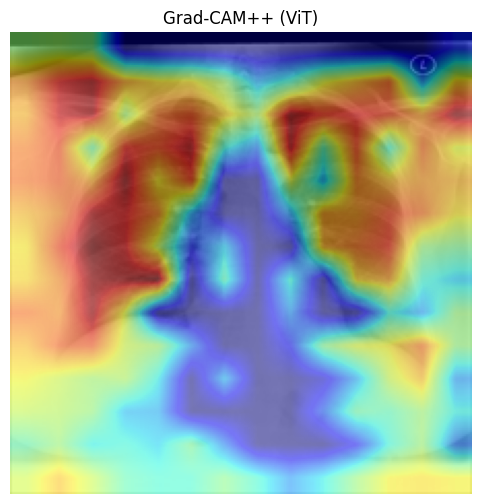

In [81]:
image_path = "/kaggle/input/tuberculosisdata/TB_Data/Test/Normal/Normal-1009.png"
gradcam_plus_plus_vit_correct(vit_model, image_path)

In [82]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

def smoothgrad_vit_correct(vit_model, image_path, samples=20, noise_level=0.1):

    vit_model.eval()
    vit_model.cpu()

    image = Image.open(image_path).convert("RGB").resize((224,224))
    input_tensor = transform(image).unsqueeze(0)

    smooth_grad = torch.zeros_like(input_tensor)

    for _ in range(samples):

        noise = torch.randn_like(input_tensor) * noise_level

        # Create noisy input
        noisy_input = (input_tensor + noise).clone().detach()
        noisy_input.requires_grad = True

        # Forward
        output = vit_model(noisy_input)
        probs = torch.softmax(output, dim=1)

        pred_class = probs.argmax()

        # Backward
        vit_model.zero_grad()
        output[0, pred_class].backward()

        # ✅ Safe gradient accumulation
        if noisy_input.grad is not None:
            smooth_grad += noisy_input.grad.detach()

    smooth_grad /= samples

    # Convert to heatmap
    grad = smooth_grad.squeeze().permute(1,2,0).cpu().numpy()
    heatmap = grad.mean(axis=2)

    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    # Plot
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.imshow(heatmap, cmap='hot', alpha=0.5)
    plt.title("SmoothGrad (ViT)")
    plt.axis("off")

    # Output
    confidence = probs.max().item() * 100
    prediction = class_names[pred_class.item()]

    print("\nPrediction:", prediction)
    print("Confidence Score:", round(confidence,2), "%")

    print("\nExplanation:")
    if prediction == "Tuberculosis":
        print("SmoothGrad highlights pixel-level regions contributing to Tuberculosis prediction with reduced noise.")
    else:
        print("SmoothGrad highlights important pixels supporting Normal lung classification.")


Prediction: Normal
Confidence Score: 95.07 %

Explanation:
SmoothGrad highlights important pixels supporting Normal lung classification.


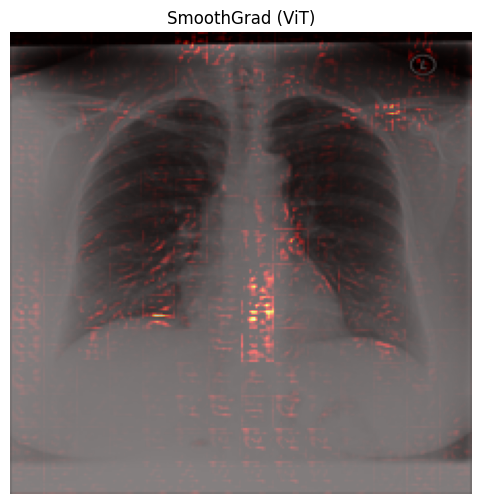

In [83]:
image_path = "/kaggle/input/tuberculosisdata/TB_Data/Test/Normal/Normal-1009.png"
smoothgrad_vit_correct(vit_model, image_path)


Prediction: Tuberculosis
Confidence Score: 95.59 %

Explanation:
SmoothGrad highlights pixel-level regions contributing to Tuberculosis prediction with reduced noise.


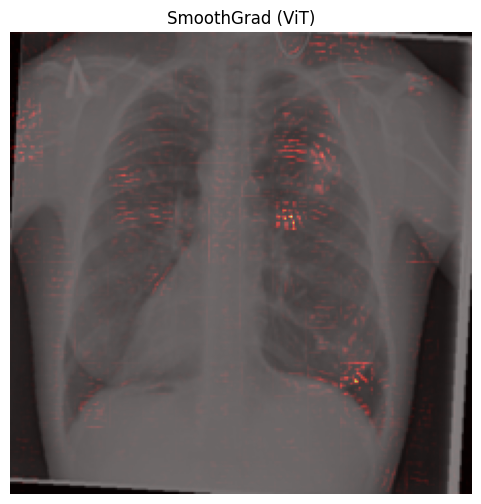

In [84]:
image_path = "/kaggle/input/tuberculosisdata/TB_Data/Test/Tuberculosis/Tuberculosis-113_aug0.png"
smoothgrad_vit_correct(vit_model, image_path)

In [85]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def occlusion_vit_correct(vit_model, image_path, patch_size=16):

    vit_model.eval()
    vit_model.cpu()

    image = Image.open(image_path).convert("RGB").resize((224,224))
    input_tensor = transform(image).unsqueeze(0)

    # Forward (original)
    with torch.no_grad():
        output = vit_model(input_tensor)
        probs = torch.softmax(output, dim=1)

    confidence, pred_class = torch.max(probs, 1)
    prediction = class_names[pred_class.item()]
    
    # keep raw probability (NOT percentage)
    base_prob = confidence.item()

    heatmap = np.zeros((224,224))

    for i in range(0, 224, patch_size):
        for j in range(0, 224, patch_size):

            occluded = input_tensor.clone()

            # ✅ better baseline (mean value)
            occluded[:, :, i:i+patch_size, j:j+patch_size] = input_tensor.mean()

            with torch.no_grad():
                out = vit_model(occluded)
                prob = torch.softmax(out, dim=1)[0, pred_class].item()

            # ✅ correct importance
            importance = base_prob - prob

            heatmap[i:i+patch_size, j:j+patch_size] = importance

    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    # Plot
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.title("Occlusion (ViT)")
    plt.axis("off")

    # Output
    print("\nPrediction:", prediction)
    print("Confidence Score:", round(base_prob*100, 2), "%")

    print("\nExplanation:")
    if prediction == "Tuberculosis":
        print("Occlusion identifies important patches where masking reduces confidence, indicating abnormal lung regions.")
    else:
        print("Occlusion shows stable predictions across regions, indicating normal lung structure.")


Prediction: Tuberculosis
Confidence Score: 95.66 %

Explanation:
Occlusion identifies important patches where masking reduces confidence, indicating abnormal lung regions.


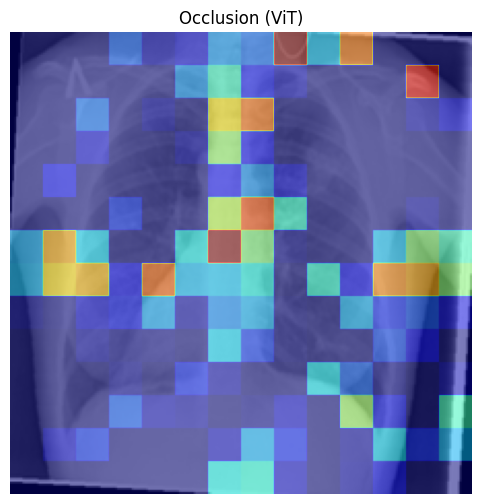

In [86]:
image_path = "/kaggle/input/tuberculosisdata/TB_Data/Test/Tuberculosis/Tuberculosis-113_aug0.png"
occlusion_vit_correct(vit_model, image_path)


Prediction: Normal
Confidence Score: 95.17 %

Explanation:
Occlusion shows stable predictions across regions, indicating normal lung structure.


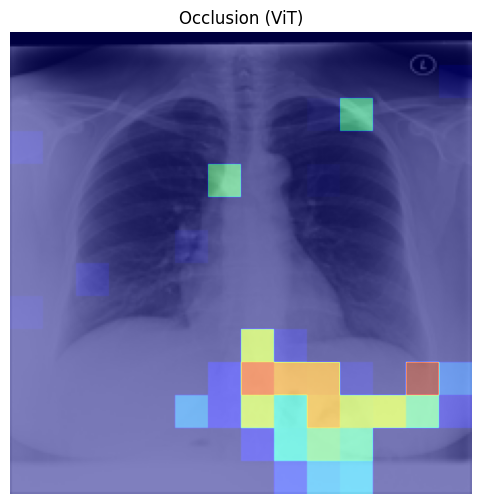

In [87]:
image_path = "/kaggle/input/tuberculosisdata/TB_Data/Test/Normal/Normal-1009.png"
occlusion_vit_correct(vit_model, image_path)